In [3]:
import pandas as pd

data = {
    "Name": ["Asha", "Ravi", "Priya"],
    "Department": ["HR", "IT", "Finance"],
    "Salary": [40000, 60000, 55000]
}

df = pd.DataFrame(data)
print(df)

    Name Department  Salary
0   Asha         HR   40000
1   Ravi         IT   60000
2  Priya    Finance   55000


# Pandas Library to perform operations 
# Most important for Data Analyst interviews.


Read file

In [4]:
df = pd.read_csv("employees.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'employees.csv'

In [20]:

df.head()

,Name,Department,Salary
0,Asha,HR,40000
1,Ravi,IT,60000
2,Priya,Finance,55000


In [6]:
df.tail()

,Name,Department,Salary
0,Asha,HR,40000
1,Ravi,IT,60000
2,Priya,Finance,55000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Name        3 non-null      object
 1   Department  3 non-null      object
 2   Salary      3 non-null      int64 
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


In [8]:
df.describe()

,Salary
count,3.000000
mean,51666.666667
std,10408.329997
min,40000.000000
25%,47500.000000
50%,55000.000000
75%,57500.000000
max,60000.000000


In [10]:
df.shape

(3, 3)

In [11]:
df.columns

Index(['Name', 'Department', 'Salary'], dtype='object')

In [12]:
df["Salary"]

0    40000
1    60000
2    55000
Name: Salary, dtype: int64

In [13]:
df[["Name", "Salary"]]

,Name,Salary
0,Asha,40000
1,Ravi,60000
2,Priya,55000


In [14]:
df[df["Salary"] > 50000]

,Name,Department,Salary
1,Ravi,IT,60000
2,Priya,Finance,55000


In [15]:
df[df["Department"] == "IT"]

,Name,Department,Salary
1,Ravi,IT,60000


In [18]:
df.sort_values(by="Salary", ascending=True)

,Name,Department,Salary
0,Asha,HR,40000
2,Priya,Finance,55000
1,Ravi,IT,60000


# Data Cleaning in Python


### check missnig values 

In [21]:
df.isnull().sum()

Name          0
Department    0
Salary        0
dtype: int64

### Fill missing values 

In [22]:
df["Salary"]=df["Salary"].fillna(df["Salary"].median())

### Drop Missing rows 

In [23]:
df.dropna()

,Name,Department,Salary
0,Asha,HR,40000
1,Ravi,IT,60000
2,Priya,Finance,55000


### remove duplicates 

In [24]:
df.drop_duplicates

<bound method DataFrame.drop_duplicates of     Name Department  Salary
0   Asha         HR   40000
1   Ravi         IT   60000
2  Priya    Finance   55000>

### Rename columns

In [25]:
df.rename(columns={"Salary":"Monthly_salary"},inplace=True)

### Change Datatype

In [26]:
df["Salary"]=df["Salary"].astype(float)

KeyError: 'Salary'

# Data Analysis with Pandas

In [28]:
import pandas as pd

data = {
    "Name": ["Asha", "Ravi", "Priya", "Asha", "Ravi", "Priya", "Kiran"],
    "Department": ["IT", "HR", "IT", "IT", "HR", "Finance", "Finance"],
    "Salary": [50000, 40000, 60000, 55000, 42000, 65000, 45000],
    "Experience": [2, 3, 4, 3, 4, 5, 2]
}

df = pd.DataFrame(data)

print(df)

    Name Department  Salary  Experience
0   Asha         IT   50000           2
1   Ravi         HR   40000           3
2  Priya         IT   60000           4
3   Asha         IT   55000           3
4   Ravi         HR   42000           4
5  Priya    Finance   65000           5
6  Kiran    Finance   45000           2


In [29]:
df.count()

Name          7
Department    7
Salary        7
Experience    7
dtype: int64

### Group by 

In [33]:
df.groupby("Department")["Salary"].sum()

Department
Finance    110000
HR          82000
IT         165000
Name: Salary, dtype: int64

### Average salary by Department

In [34]:
df.groupby("Department")["Salary"].mean()

Department
Finance    55000.0
HR         41000.0
IT         55000.0
Name: Salary, dtype: float64

### Count employees in each Department

In [38]:
df.groupby("Department")["Name"].count()

Department
Finance    2
HR         2
IT         3
Name: Name, dtype: int64

### Multiple aggregations

In [41]:
df.groupby("Department")["Salary"].agg(["sum","min","max","mean","count"])

,sum,min,max,mean,count
Department,,,,,
Finance,110000,45000,65000,55000.0,2
HR,82000,40000,42000,41000.0,2
IT,165000,50000,60000,55000.0,3


## Group by multiple columns

In [42]:
df.groupby(["Department", "Name"])["Salary"].sum()

Department  Name 
Finance     Kiran     45000
            Priya     65000
HR          Ravi      82000
IT          Asha     105000
            Priya     60000
Name: Salary, dtype: int64

## Filter data

In [43]:
df[df["Salary"] > 50000]

,Name,Department,Salary,Experience
2,Priya,IT,60000,4
3,Asha,IT,55000,3
5,Priya,Finance,65000,5


### create a new coloumn

In [44]:
df["Annual_Salary"] = df["Salary"] * 12

In [45]:
print(df)

    Name Department  Salary  Experience  Annual_Salary
0   Asha         IT   50000           2         600000
1   Ravi         HR   40000           3         480000
2  Priya         IT   60000           4         720000
3   Asha         IT   55000           3         660000
4   Ravi         HR   42000           4         504000
5  Priya    Finance   65000           5         780000
6  Kiran    Finance   45000           2         540000


### Apply function

In [46]:
df["Salary_Category"] = df["Salary"].apply(
    lambda x: "High" if x > 50000 else "Low"
)

In [47]:
print(df)

    Name Department  Salary  Experience  Annual_Salary Salary_Category
0   Asha         IT   50000           2         600000             Low
1   Ravi         HR   40000           3         480000             Low
2  Priya         IT   60000           4         720000            High
3   Asha         IT   55000           3         660000            High
4   Ravi         HR   42000           4         504000             Low
5  Priya    Finance   65000           5         780000            High
6  Kiran    Finance   45000           2         540000             Low


## Joins / Merge in Pandas

### INNER JOIN

In [49]:
employees=pd.DataFrame({
    "emp_id":[1,2,3],
    "name":["Asha","Ravi","Pushpa"]
})
salary=pd.DataFrame({
    "emp_id":[1,12,4],
    "salary":[40000,50000,60000]
})
merged=pd.merge(employees,salary,on="emp_id",how="inner")
print(merged)

   emp_id  name  salary
0       1  Asha   40000


### LEFT JOIN

In [50]:
merged=pd.merge(employees,salary,on="emp_id",how="left")
print(merged)

   emp_id    name   salary
0       1    Asha  40000.0
1       2    Ravi      NaN
2       3  Pushpa      NaN


## Right Join

In [51]:

merged = pd.merge(employees, salary, on="emp_id", how="right")
print(merged)

   emp_id  name  salary
0       1  Asha   40000
1      12   NaN   50000
2       4   NaN   60000


### OUTER JOIN

In [52]:


merged = pd.merge(employees, salary, on="emp_id", how="outer")
print(merged)

   emp_id    name   salary
0       1    Asha  40000.0
1       2    Ravi      NaN
2       3  Pushpa      NaN
3       4     NaN  60000.0
4      12     NaN  50000.0


# Date Handling

In [62]:
import pandas as pd

data = {
    "Name": ["Asha", "Ravi", "Priya", "Kiran"],
    "Date": ["2024-01-15", "2024-02-20", "2024-02-25", "2024-03-10"],
    "Sales": [5000, 7000, 3000, 9000]
}

df = pd.DataFrame(data)

In [63]:
print(df)

    Name        Date  Sales
0   Asha  2024-01-15   5000
1   Ravi  2024-02-20   7000
2  Priya  2024-02-25   3000
3  Kiran  2024-03-10   9000


## Convert column to date format

In [64]:
df["Date"]=pd.to_datetime(df["Date"])

## Extract year, month, day

In [65]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [66]:
print(df)

    Name       Date  Sales  Year  Month  Day
0   Asha 2024-01-15   5000  2024      1   15
1   Ravi 2024-02-20   7000  2024      2   20
2  Priya 2024-02-25   3000  2024      2   25
3  Kiran 2024-03-10   9000  2024      3   10


## Get month name and day name

In [67]:
df["Month_Name"] = df["Date"].dt.month_name()
df["Day_Name"] = df["Date"].dt.day_name()

In [68]:
print(df)

    Name       Date  Sales  Year  Month  Day Month_Name Day_Name
0   Asha 2024-01-15   5000  2024      1   15    January   Monday
1   Ravi 2024-02-20   7000  2024      2   20   February  Tuesday
2  Priya 2024-02-25   3000  2024      2   25   February   Sunday
3  Kiran 2024-03-10   9000  2024      3   10      March   Sunday


## Filter data by date

In [69]:
df[df["Date"]>"2024-02-01"]

,Name,Date,Sales,Year,Month,Day,Month_Name,Day_Name
1,Ravi,2024-02-20,7000,2024,2,20,February,Tuesday
2,Priya,2024-02-25,3000,2024,2,25,February,Sunday
3,Kiran,2024-03-10,9000,2024,3,10,March,Sunday


## Group data month-wise

In [70]:
df.groupby("Month")["Sales"].sum()

Month
1     5000
2    10000
3     9000
Name: Sales, dtype: int64

## Sort by date

In [71]:
df.sort_values(by="Date")

,Name,Date,Sales,Year,Month,Day,Month_Name,Day_Name
0,Asha,2024-01-15,5000,2024,1,15,January,Monday
1,Ravi,2024-02-20,7000,2024,2,20,February,Tuesday
2,Priya,2024-02-25,3000,2024,2,25,February,Sunday
3,Kiran,2024-03-10,9000,2024,3,10,March,Sunday


In [72]:
df.sort_values(by="Date", ascending=False)

,Name,Date,Sales,Year,Month,Day,Month_Name,Day_Name
3,Kiran,2024-03-10,9000,2024,3,10,March,Sunday
2,Priya,2024-02-25,3000,2024,2,25,February,Sunday
1,Ravi,2024-02-20,7000,2024,2,20,February,Tuesday
0,Asha,2024-01-15,5000,2024,1,15,January,Monday


In [75]:
df.sort_values(by="Date",ascending=False)

,Name,Date,Sales,Year,Month,Day,Month_Name,Day_Name,Days_From_Today
3,Kiran,2024-03-10,9000,2024,3,10,March,Sunday,799 days 22:48:24.471743
2,Priya,2024-02-25,3000,2024,2,25,February,Sunday,813 days 22:48:24.471743
1,Ravi,2024-02-20,7000,2024,2,20,February,Tuesday,818 days 22:48:24.471743
0,Asha,2024-01-15,5000,2024,1,15,January,Monday,854 days 22:48:24.471743


In [82]:
df["Days_From_Today"]=pd.Timestamp.today() - df["Date"]

In [83]:
df["Date"] = pd.to_datetime(df["Date"])

In [84]:
print(df)

    Name       Date  Sales  Year  Month  Day Month_Name Day_Name  \
0   Asha 2024-01-15   5000  2024      1   15    January   Monday   
1   Ravi 2024-02-20   7000  2024      2   20   February  Tuesday   
2  Priya 2024-02-25   3000  2024      2   25   February   Sunday   
3  Kiran 2024-03-10   9000  2024      3   10      March   Sunday   

           Days_From_Today  
0 854 days 22:50:44.587423  
1 818 days 22:50:44.587423  
2 813 days 22:50:44.587423  
3 799 days 22:50:44.587423  


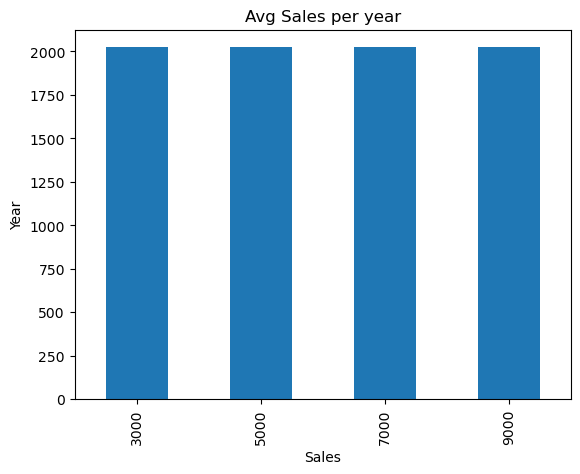

In [86]:
import matplotlib.pyplot as plt
df.groupby("Sales")["Year"].mean().plot(kind="bar")
plt.title("Avg Sales per year")
plt.xlabel("Sales")
plt.ylabel("Year")
plt.show()

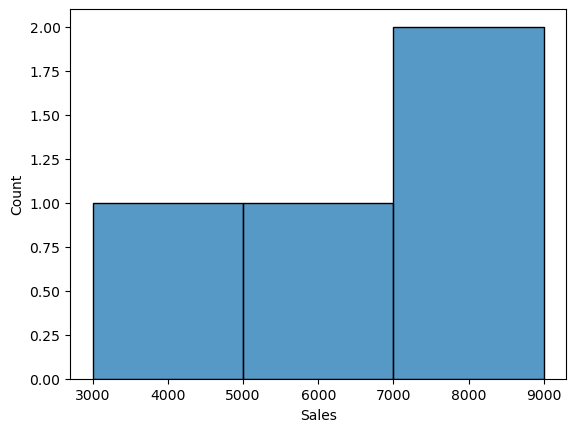

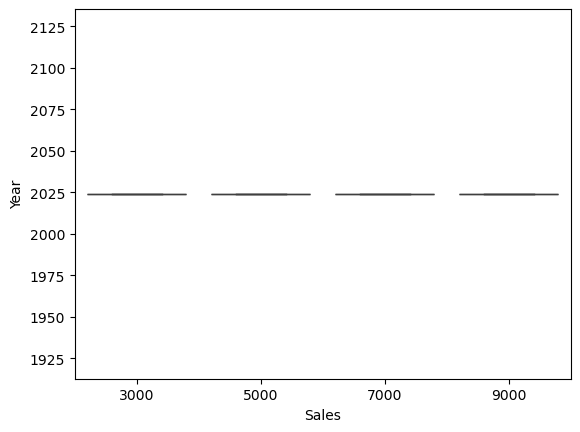

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df["Sales"])
plt.show()
sns.boxplot(x="Sales",y="Year",data=df)
plt.show()

## What is the difference between loc and iloc?

In [90]:
df.loc[0, "Name"]

'Asha'

In [91]:
df.iloc[0, 1]

Timestamp('2024-01-15 00:00:00')

### What is lambda function?

### A lambda function is a small anonymous function used for short operations.

In [92]:
square=lambda x:x*x
print(square(5))

25


## How do you find correlation?

In [93]:
df.corr(numeric_only=True)

,Sales,Year,Month,Day
Sales,1.000000,NaN,0.632456,-0.800000
Year,NaN,NaN,NaN,NaN
Month,0.632456,NaN,1.000000,-0.316228
Day,-0.800000,NaN,-0.316228,1.000000


## Find attrition rate

In [95]:
import pandas as pd

data = {
    "Employee": ["Asha", "Ravi", "Priya", "Kiran", "John"],
    "Attrition": ["Yes", "No", "Yes", "No", "No"]
}

df = pd.DataFrame(data)

print(df)

  Employee Attrition
0     Asha       Yes
1     Ravi        No
2    Priya       Yes
3    Kiran        No
4     John        No


In [96]:
attrition_rate = (df[df["Attrition"] == "Yes"].shape[0] / df.shape[0]) * 100
print(attrition_rate)

40.0


EDA